In [91]:
import pandas as pd

# Load the clip labels created from Process_boxes_to_classifier_labels.ipynb
train_set = pd.read_csv('train_set_onehot.csv')
val_set = pd.read_csv('val_set_onehot.csv')
test_set = pd.read_csv('test_set_onehot.csv')

# concat all subsets in dataset df
dataset_df = pd.concat([train_set, val_set, test_set], ignore_index=True)

dataset_df

,file,start_time,end_time,calltype_A,calltype_B,calltype_C,calltype_Check,calltype_Cheer,calltype_Chits,calltype_D,calltype_E,calltype_G,calltype_J,calltype_K
0,/home/Shelby/blackbird_calls/Experiments/Detec...,0.0,3.0,False,False,False,False,False,False,True,False,False,False,False
1,/home/Shelby/blackbird_calls/Experiments/Detec...,0.0,3.0,False,False,False,False,True,False,False,False,False,False,False
2,/home/Shelby/blackbird_calls/Experiments/Detec...,0.0,3.0,False,False,False,True,False,False,False,False,False,False,False
3,/home/Shelby/blackbird_calls/Experiments/Detec...,0.0,3.0,False,False,False,False,True,False,False,False,False,False,False
4,/home/Shelby/blackbird_calls/Experiments/Detec...,0.0,3.0,False,False,False,True,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5728,/home/Shelby/blackbird_calls/Experiments/Detec...,0.0,3.0,False,False,False,False,False,False,False,False,False,True,False
5729,/home/Shelby/blackbird_calls/Experiments/Detec...,0.0,3.0,False,False,False,False,False,False,True,False,False,False,False
5730,/home/Shelby/blackbird_calls/Experiments/Detec...,0.0,3.0,False,False,False,True,False,False,False,False,False,False,False
5731,/home/Shelby/blackbird_calls/Experiments/Detec...,0.0,3.0,False,False,False,True,False,False,False,False,False,False,False


In [92]:
classes = dataset_df.columns[3:].tolist()
classes

['calltype_A',
 'calltype_B',
 'calltype_C',
 'calltype_Check',
 'calltype_Cheer',
 'calltype_Chits',
 'calltype_D',
 'calltype_E',
 'calltype_G',
 'calltype_J',
 'calltype_K']

In [93]:
# make index file and start time and end time
train_set = train_set.reset_index(drop=True)
val_set = val_set.reset_index(drop=True)
test_set = test_set.reset_index(drop=True)

# train_set.set_index(['file', 'start_time', 'end_time'], inplace=True)
# val_set.set_index(['file', 'start_time', 'end_time'], inplace=True)
# test_set.set_index(['file', 'start_time', 'end_time'], inplace=True)

optional: upsampling or downsampling

In [94]:
train_set.head()

,file,start_time,end_time,calltype_A,calltype_B,calltype_C,calltype_Check,calltype_Cheer,calltype_Chits,calltype_D,calltype_E,calltype_G,calltype_J,calltype_K
0,/home/Shelby/blackbird_calls/Experiments/Detec...,0.0,3.0,False,False,False,False,False,False,True,False,False,False,False
1,/home/Shelby/blackbird_calls/Experiments/Detec...,0.0,3.0,False,False,False,False,True,False,False,False,False,False,False
2,/home/Shelby/blackbird_calls/Experiments/Detec...,0.0,3.0,False,False,False,True,False,False,False,False,False,False,False
3,/home/Shelby/blackbird_calls/Experiments/Detec...,0.0,3.0,False,False,False,False,True,False,False,False,False,False,False
4,/home/Shelby/blackbird_calls/Experiments/Detec...,0.0,3.0,False,False,False,True,False,False,False,False,False,False,False


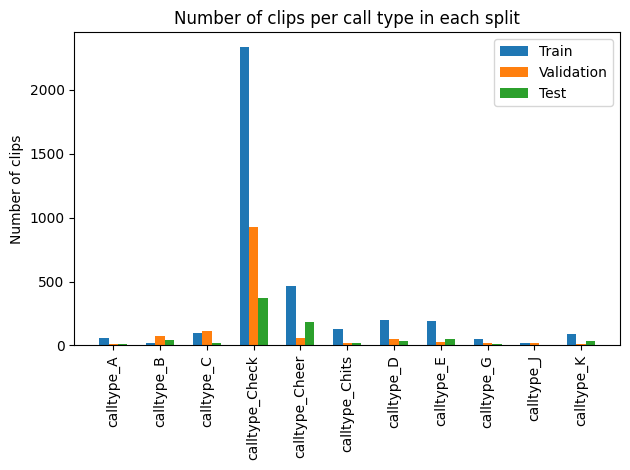

In [95]:
# bar plot number of calltype files in each split
import matplotlib.pyplot as plt
calltype_columns = [col for col in classes if col.startswith('calltype_')]
train_counts = train_set[calltype_columns].sum()
val_counts = val_set[calltype_columns].sum()
test_counts = test_set[calltype_columns].sum()
x = range(len(calltype_columns))
plt.bar(x, train_counts, width=0.2, label='Train')
plt.bar([i + 0.2 for i in x], val_counts, width=0.2, label='Validation')
plt.bar([i + 0.4 for i in x], test_counts, width=0.2, label='Test')
plt.xticks([i + 0.2 for i in x], calltype_columns, rotation=90)
plt.ylabel('Number of clips')
plt.title('Number of clips per call type in each split')
plt.legend()
plt.tight_layout()
plt.show()

In [96]:
# print table of number of calltype files in each split
split_summary = pd.DataFrame({
    'Train': train_counts,
    'Validation': val_counts,
    'Test': test_counts
})
split_summary

,Train,Validation,Test
calltype_A,55,9,12
calltype_B,17,74,45
calltype_C,97,112,19
calltype_Check,2333,930,367
calltype_Cheer,464,59,184
calltype_Chits,125,18,19
calltype_D,195,47,34
calltype_E,192,29,51
calltype_G,47,18,12
calltype_J,19,16,4


### resample

In [97]:
# resample train set by upsampling minority classes
seed = 42

def resample_set(df, n_samples_per_class, seed=42, downsample=True, upsample=True):
    """
    Resample a multi-label dataset to have n_samples_per_class for each class.
    For upsampling: duplicates rows as needed (keeps duplicates)
    For downsampling: randomly selects subset of samples
    """
    resampled_dfs = []
    
    # Get label columns (exclude metadata columns)
    label_cols = [col for col in df.columns if col not in ['file', 'start_time', 'end_time']]
    
    for class_label in label_cols:
        # Get rows that have this class
        class_df = df[df[class_label] == 1].copy()
        
        if len(class_df) == 0:
            print(f"Warning: No samples found for {class_label}")
            continue
        
        # Sample with or without replacement depending on class size
        if len(class_df) < n_samples_per_class and upsample:
            # Upsample with replacement - this creates duplicates
            sampled_df = class_df.sample(
                n=n_samples_per_class, replace=True, random_state=seed
            )
            new_number = len(sampled_df)
            print(f"Upsampled {class_label} from {len(class_df)} to {new_number} clips.")
        elif len(class_df) > n_samples_per_class and downsample:
            # Downsample
            sampled_df = class_df.sample(
                n=n_samples_per_class, replace=False, random_state=seed
            )

            new_number = len(sampled_df)
            print(f"Downsampled {class_label} from {len(class_df)} to {new_number} clips.")
        else:
            sampled_df = class_df
        resampled_dfs.append(sampled_df)
    
    # Concatenate all resampled dataframes and remove duplicates
    # (a clip can appear multiple times if it belongs to multiple classes that were all upsampled)
    resampled_set = pd.concat(resampled_dfs, axis=0)
    resampled_set = resampled_set.reset_index(drop=True)
    
    print(f"\nTotal unique clips after resampling: {len(resampled_set)}")
    
    # Show per-class counts after resampling
    print("\nPer-class counts after resampling:")
    for col in label_cols:
        count = resampled_set[col].sum()
        print(f"  {col}: {count}")
    
    return resampled_set

In [98]:
RESAMPLE = True
RESAMPLE_VAL = True
DOWNSAMPLE = True
UPSAMPLE = True

if RESAMPLE:
    resampled_train_set = resample_set(train_set, 100, seed, downsample=DOWNSAMPLE, upsample=UPSAMPLE)
    resampled_train_set.set_index(['file', 'start_time', 'end_time'], inplace=True)
    print("\nResampled training set created.")
    if RESAMPLE_VAL:
        resampled_val_set = resample_set(val_set, 100, seed, downsample=DOWNSAMPLE, upsample=False)
        print("\nResampled validation set created.")
    else:
        resampled_val_set = val_set.copy()
    resampled_val_set.set_index(['file', 'start_time', 'end_time'], inplace=True)  
    test_set.set_index(['file', 'start_time', 'end_time'], inplace=True)
else:
    resampled_train_set = train_set.set_index(['file', 'start_time', 'end_time'])
    resampled_val_set = val_set.set_index(['file', 'start_time', 'end_time'])
    test_set.set_index(['file', 'start_time', 'end_time'], inplace=True)

Upsampled calltype_A from 55 to 100 clips.
Upsampled calltype_B from 17 to 100 clips.
Upsampled calltype_C from 97 to 100 clips.
Downsampled calltype_Check from 2333 to 100 clips.
Downsampled calltype_Cheer from 464 to 100 clips.
Downsampled calltype_Chits from 125 to 100 clips.
Downsampled calltype_D from 195 to 100 clips.
Downsampled calltype_E from 192 to 100 clips.
Upsampled calltype_G from 47 to 100 clips.
Upsampled calltype_J from 19 to 100 clips.
Upsampled calltype_K from 88 to 100 clips.

Total unique clips after resampling: 1100

Per-class counts after resampling:
  calltype_A: 100
  calltype_B: 100
  calltype_C: 100
  calltype_Check: 100
  calltype_Cheer: 100
  calltype_Chits: 100
  calltype_D: 100
  calltype_E: 100
  calltype_G: 100
  calltype_J: 100
  calltype_K: 100

Resampled training set created.
Downsampled calltype_C from 112 to 100 clips.
Downsampled calltype_Check from 930 to 100 clips.

Total unique clips after resampling: 481

Per-class counts after resampling:
  c

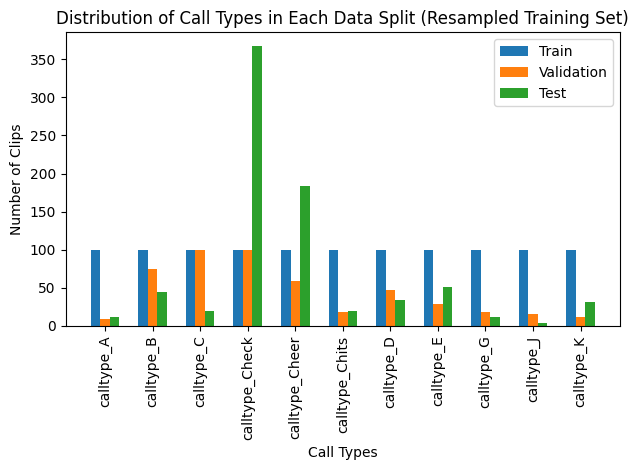

In [99]:
# bar plot number of calltype files in each split resampled
import matplotlib.pyplot as plt
calltype_columns = [col for col in dataset_df.columns if col.startswith('calltype_')]
train_counts = resampled_train_set[calltype_columns].sum()
val_counts = resampled_val_set[calltype_columns].sum()
test_counts = test_set[calltype_columns].sum()
x = range(len(calltype_columns))
plt.bar(x, train_counts, width=0.2, label='Train')
plt.bar([i + 0.2 for i in x], val_counts, width=0.2, label='Validation')
plt.bar([i + 0.4 for i in x], test_counts, width=0.2, label='Test')
plt.xticks([i + 0.2 for i in x], calltype_columns, rotation=90)
plt.xlabel('Call Types')
plt.ylabel('Number of Clips')
plt.title('Distribution of Call Types in Each Data Split (Resampled Training Set)')
plt.legend()
plt.tight_layout()
plt.show()

In [100]:
# read in the training, validation and test set
import pandas as pd
import bioacoustics_model_zoo as bmz
import torch
import numpy as np

# Allow numpy types to be loaded
torch.serialization.add_safe_globals([np.float32, np.float64, np.int32, np.int64])

birdnet = bmz.BirdNET()
#train_set = pd.read_csv('resampled_train_set.csv', index_col=[0,1,2])
#val_set = pd.read_csv('validation_set.csv', index_col=[0,1,2])

downloading model from URL...


/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/opensoundscape/ml/cnn.py:599: UserWarning: 
                    This architecture is not listed in opensoundscape.ml.cnn_architectures.ARCH_DICT.
                    It will not be available for loading after saving the model with .save() (unless using pickle=True). 
                    To make it re-loadable, define a function that generates the architecture from arguments: (n_classes, n_channels) 
                    then use opensoundscape.ml.cnn_architectures.register_architecture() to register the generating function.

                    The function can also set the returned object's .constructor_name to the registered string key in ARCH_DICT
                    to avoid this warning and ensure it is reloaded correctly by opensoundscape.ml.load_model().

                    See opensoundscape.ml.cnn_architectures module for examples of constructor functions
                    
  warnings.warn(
/home/She

In [12]:

# emb_test = birdnet.embed(test_set, return_dfs=False, batch_size=128, num_workers=num_workers)

In [101]:
num_workers = 4

# emb_train = birdnet.embed(resampled_train_set, return_dfs=False, batch_size=128, num_workers=num_workers)
emb_val = birdnet.embed(resampled_val_set, return_dfs=False, batch_size=128, num_workers=num_workers)
emb_test = birdnet.embed(test_set, return_dfs=False, batch_size=128, num_workers=num_workers)

  0%|          | 0/4 [00:00<?, ?it/s]

/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=572838) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


  0%|          | 0/7 [00:00<?, ?it/s]

/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=572838) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


## training

In [102]:
# We want to train the classifier on the 'A' class here, corresponding to the primary R. sierrae call type.
# Let's replace fc output layer with 1-output layer for class 'A'
classes = list(resampled_train_set.columns)
birdnet.change_classes(classes)

# Convert all label columns to float to avoid object type errors
resampled_train_set = resampled_train_set.astype(float)
resampled_val_set = resampled_val_set.astype(float)
test_set = test_set.astype(float)
# Convert labels to float (in case they're boolean or object type)
train_labels = resampled_train_set.astype(float).values
val_labels = resampled_val_set.astype(float).values
test_labels = test_set.astype(float).values

# fit the classification head with embeddings and labels
# birdnet.network.fit(emb_train, train_labels, emb_val, val_labels)

In [103]:
import pickle
import os
import sys
from io import StringIO

# Create training directory if it doesn't exist
os.makedirs('training', exist_ok=True)

# Capture stdout to parse training metrics
captured_output = StringIO()
old_stdout = sys.stdout
sys.stdout = captured_output

try:
    # Train the model
    history = birdnet.train(
        train_df=resampled_train_set,
        validation_df=resampled_val_set,
        embedding_batch_size=128,
        embedding_num_workers=num_workers,
        # n_augmentation_variants=2,
        steps=100,
        device=0
    )
finally:
    # Restore stdout
    sys.stdout = old_stdout

# Print captured output
output = captured_output.getvalue()
print(output)

# Parse the captured output to extract metrics
import re
train_losses = []
val_losses = []
val_aurocs = []
val_maps = []
epochs = []

for line in output.split('\n'):
    # Match lines like: "Epoch 100/500, Loss: 0.03169373422861099, Val Loss: 0.11118992418050766"
    epoch_match = re.search(r'Epoch (\d+)/\d+, Loss: ([\d.]+), Val Loss: ([\d.]+)', line)
    if epoch_match:
        epochs.append(int(epoch_match.group(1)))
        train_losses.append(float(epoch_match.group(2)))
        val_losses.append(float(epoch_match.group(3)))
    
    # Match lines like: "val AU ROC: 0.923"
    auroc_match = re.search(r'val AU ROC: ([\d.]+)', line)
    if auroc_match:
        val_aurocs.append(float(auroc_match.group(1)))
    
    # Match lines like: "val MAP: 0.657"
    map_match = re.search(r'val MAP: ([\d.]+)', line)
    if map_match:
        val_maps.append(float(map_match.group(1)))

# Create history dictionary
history = {
    'epochs': epochs,
    'train_loss': train_losses,
    'val_loss': val_losses,
    'val_auroc': val_aurocs,
    'val_map': val_maps
}

print(f"\nParsed {len(epochs)} training checkpoints")

# Save training history
with open('training/training_history.pkl', 'wb') as f:
    pickle.dump(history, f)

print("Training complete. History saved to 'training/training_history.pkl'")

  0%|          | 0/9 [00:00<?, ?it/s]

/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=572838) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


  0%|          | 0/4 [00:00<?, ?it/s]

/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/opensoundscape/ml/shallow_classifier.py:110: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_features = torch.tensor(train_features, dtype=torch.float32, device=device)
/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/opensoundscape/ml/shallow_classifier.py:111: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_labels = torch.tensor(train_labels, dtype=torch.float32, device=device)
/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/opensoundscape/ml/shallow_classifier.py:115: UserWarning: To copy construct from a tensor, it is recommended to use sourceTens

Embedding the training samples without augmentation
Embedding the validation samples
Fitting the classifier
Epoch 1/100, Loss: 0.6743184328079224, Val Loss: 0.5644913911819458
val AU ROC: 0.557
val MAP: 0.188
Epoch 2/100, Loss: 0.5637478232383728, Val Loss: 0.4796951115131378
val AU ROC: 0.538
val MAP: 0.193
Epoch 3/100, Loss: 0.4772406816482544, Val Loss: 0.41599929332733154
val AU ROC: 0.524
val MAP: 0.185
Epoch 4/100, Loss: 0.412761390209198, Val Loss: 0.37050649523735046
val AU ROC: 0.515
val MAP: 0.183
Epoch 5/100, Loss: 0.3670275807380676, Val Loss: 0.3397074341773987
val AU ROC: 0.509
val MAP: 0.175
Epoch 6/100, Loss: 0.33617502450942993, Val Loss: 0.32006165385246277
val AU ROC: 0.508
val MAP: 0.172
Epoch 7/100, Loss: 0.31640398502349854, Val Loss: 0.30841687321662903
val AU ROC: 0.511
val MAP: 0.171
Epoch 8/100, Loss: 0.304408460855484, Val Loss: 0.30220723152160645
val AU ROC: 0.516
val MAP: 0.172
Epoch 9/100, Loss: 0.2975544333457947, Val Loss: 0.29947629570961
val AU ROC: 0

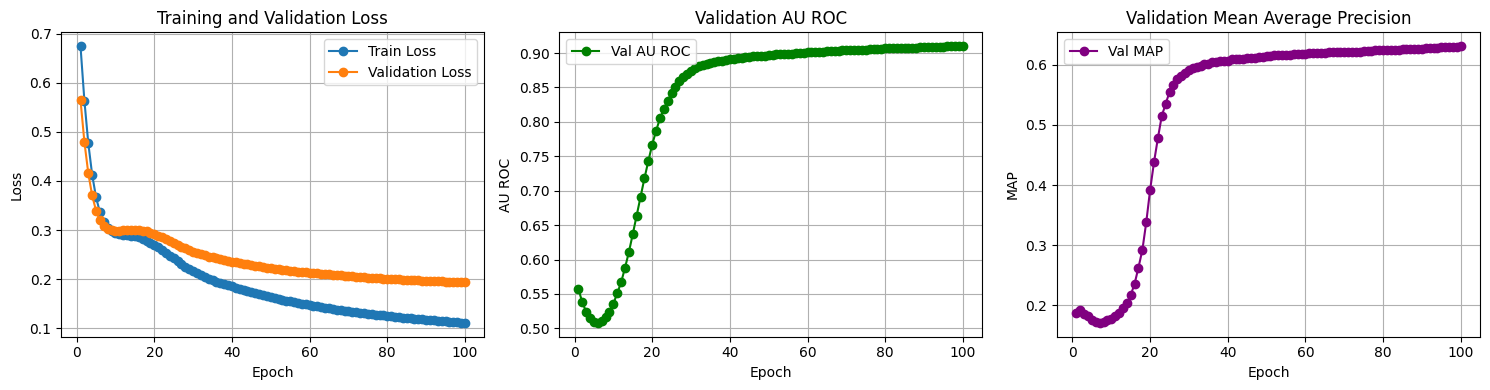


Final Metrics (Epoch 100):
  Train Loss: 0.1112
  Val Loss: 0.1937
  Val AU ROC: 0.9100
  Val MAP: 0.6310


In [104]:
# Plot training curves
import pickle
import matplotlib.pyplot as plt

# Load training history
with open('training/training_history.pkl', 'rb') as f:
    history = pickle.load(f)

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot training and validation loss
axes[0].plot(history['epochs'], history['train_loss'], 'o-', label='Train Loss')
axes[0].plot(history['epochs'], history['val_loss'], 'o-', label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

# Plot validation AU ROC
axes[1].plot(history['epochs'], history['val_auroc'], 'o-', color='green', label='Val AU ROC')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AU ROC')
axes[1].set_title('Validation AU ROC')
axes[1].legend()
axes[1].grid(True)

# Plot validation MAP
axes[2].plot(history['epochs'], history['val_map'], 'o-', color='purple', label='Val MAP')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('MAP')
axes[2].set_title('Validation Mean Average Precision')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

# Print final metrics
print(f"\nFinal Metrics (Epoch {history['epochs'][-1]}):")
print(f"  Train Loss: {history['train_loss'][-1]:.4f}")
print(f"  Val Loss: {history['val_loss'][-1]:.4f}")
print(f"  Val AU ROC: {history['val_auroc'][-1]:.4f}")
print(f"  Val MAP: {history['val_map'][-1]:.4f}")

## val predictions

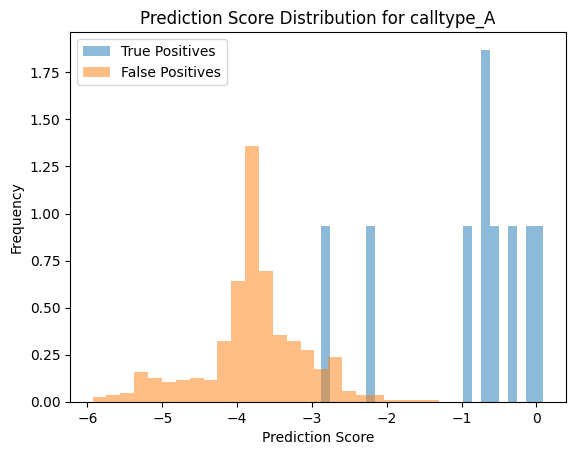

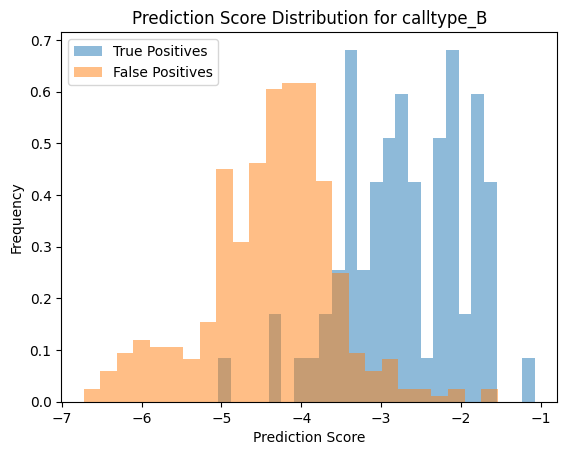

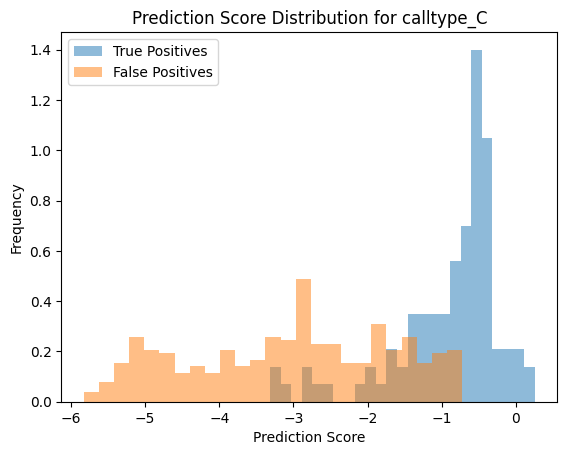

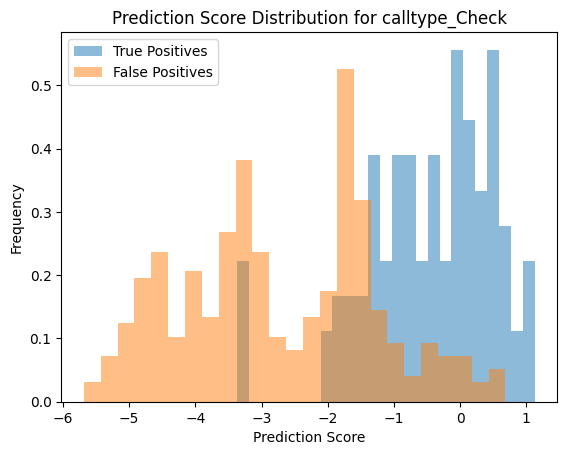

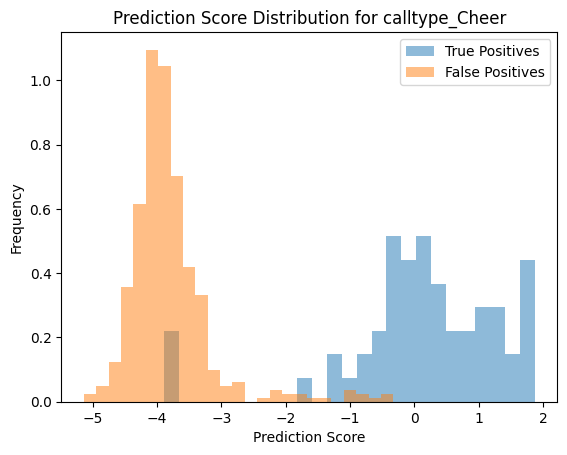

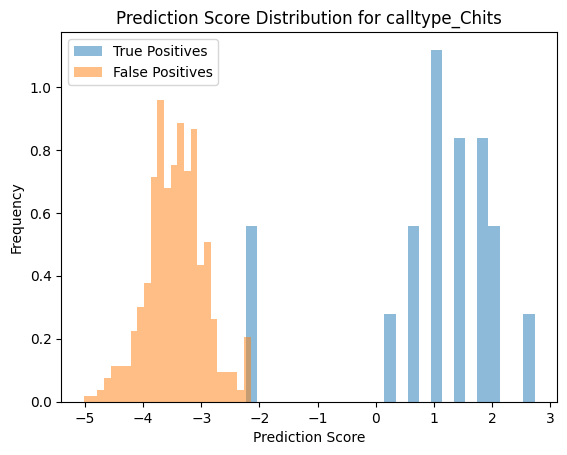

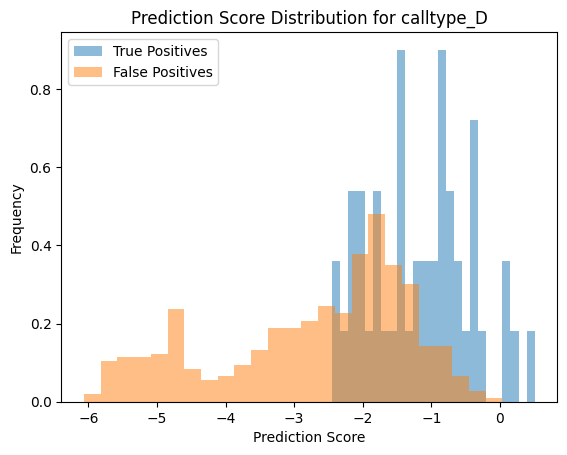

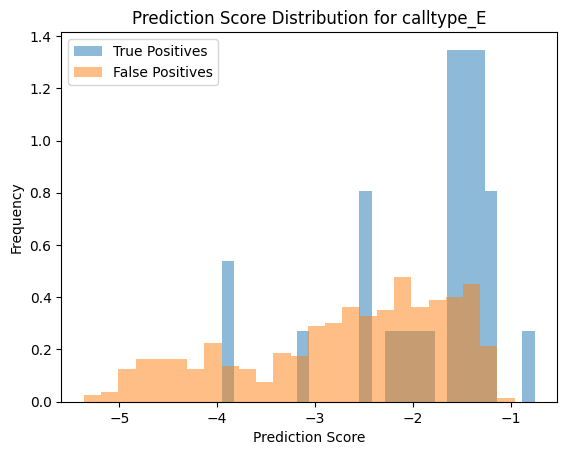

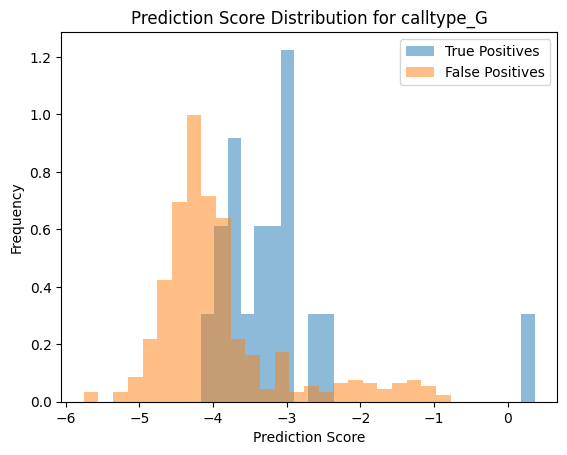

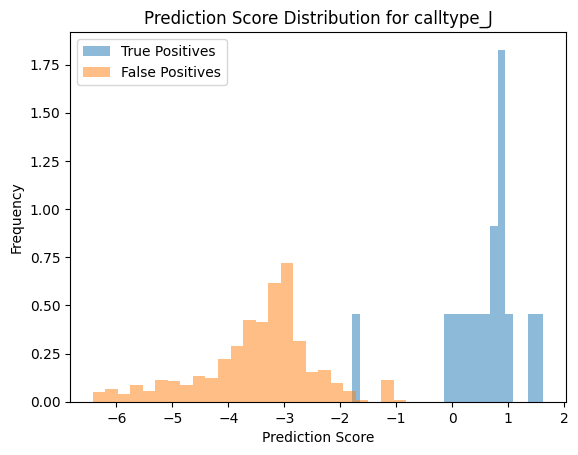

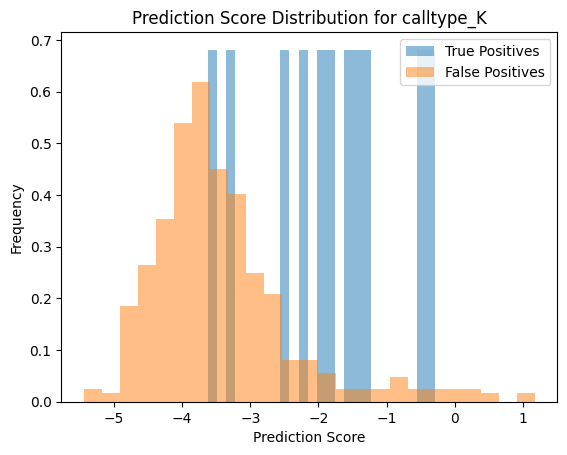

In [105]:
# Plot an histogram per calltype of the prediction scores and FP vs TP
preds = birdnet.network(torch.tensor(emb_val).cuda()).detach().cpu()

import matplotlib.pyplot as plt

for class_name in classes:
    class_idx = list(resampled_val_set.columns).index(class_name) # get index of class
    plt.figure()
    #plt.hist(preds[:, class_idx].numpy(), bins=50, alpha=0.7, label='All Predictions')
    
    # True Positives
    tp_indices = (resampled_val_set[class_name] == 1).values # get indices of true positives
    plt.hist(preds[tp_indices, class_idx].numpy(), bins=25, alpha=0.5, density=True, label='True Positives')
    
    # False Positives
    fp_indices = (resampled_val_set[class_name] == 0).values # get indices of false positives
    plt.hist(preds[fp_indices, class_idx].numpy(), bins=25, alpha=0.5, density=True, label='False Positives')
    
    plt.title(f'Prediction Score Distribution for {class_name}')
    plt.xlabel('Prediction Score')
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()

In [106]:
#can you write code for a classification report for each class?
from sklearn.metrics import classification_report
# pred class is the class with the highest score
pred_labels = np.argmax(preds.numpy(), axis=1)
resampled_val_set_labels = np.argmax(resampled_val_set.values, axis=1)
report = classification_report(resampled_val_set_labels, pred_labels, target_names=classes, zero_division=0)
print(report)

                precision    recall  f1-score   support

    calltype_A       0.71      0.56      0.62         9
    calltype_B       0.94      0.45      0.61        74
    calltype_C       0.70      0.68      0.69       100
calltype_Check       0.63      0.73      0.68       100
calltype_Cheer       0.96      0.93      0.95        59
calltype_Chits       1.00      0.89      0.94        18
    calltype_D       0.56      0.64      0.59        47
    calltype_E       0.16      0.21      0.18        29
    calltype_G       1.00      0.06      0.11        18
    calltype_J       0.44      1.00      0.62        16
    calltype_K       0.21      0.45      0.29        11

      accuracy                           0.64       481
     macro avg       0.67      0.60      0.57       481
  weighted avg       0.71      0.64      0.64       481



## test predictions

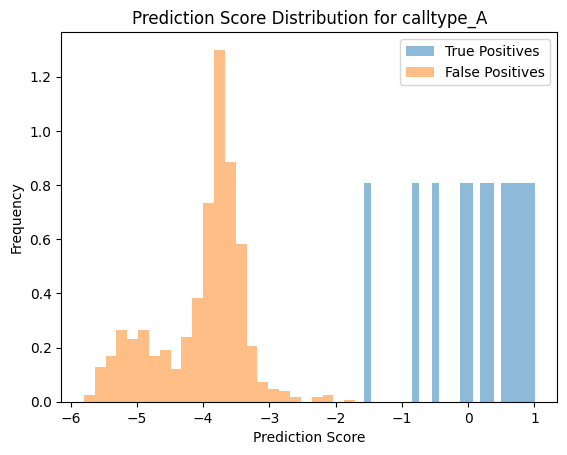

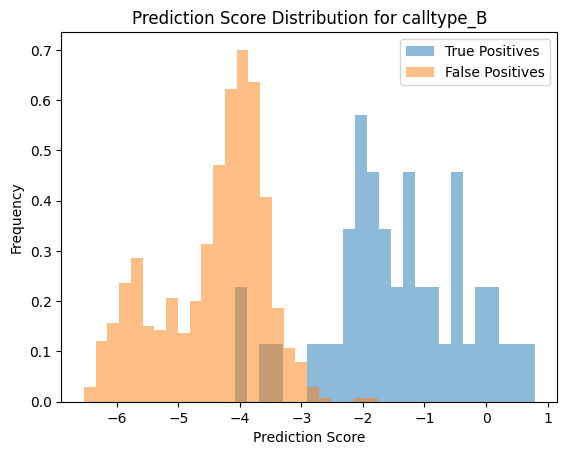

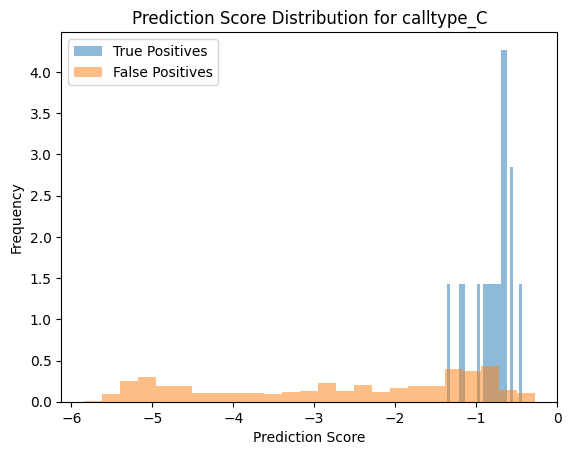

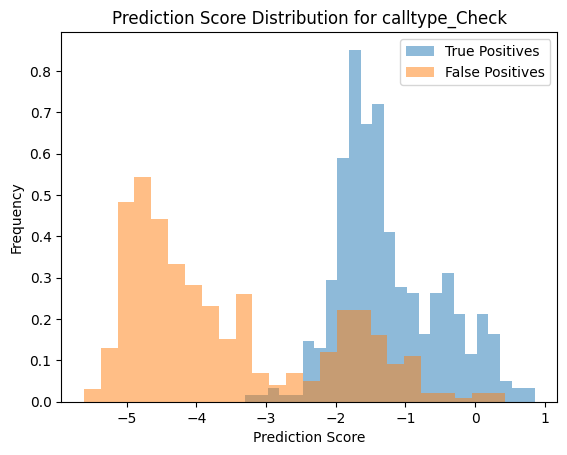

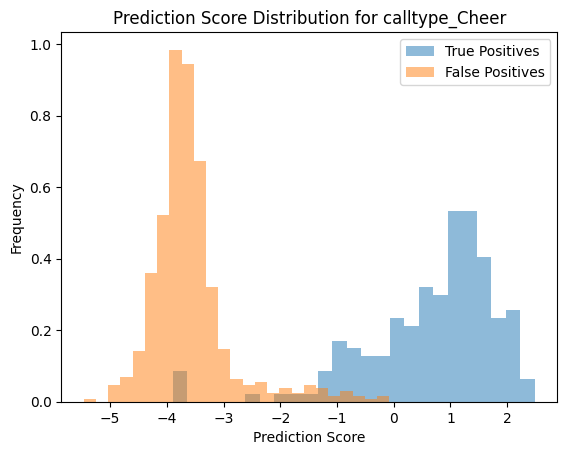

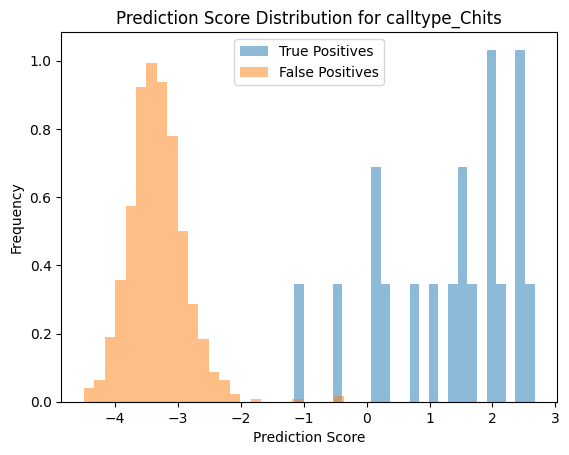

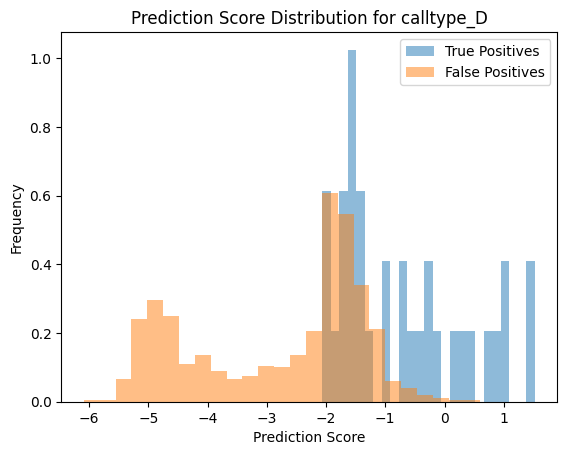

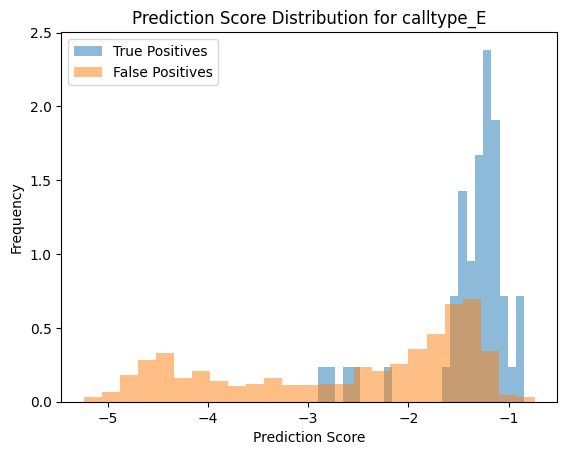

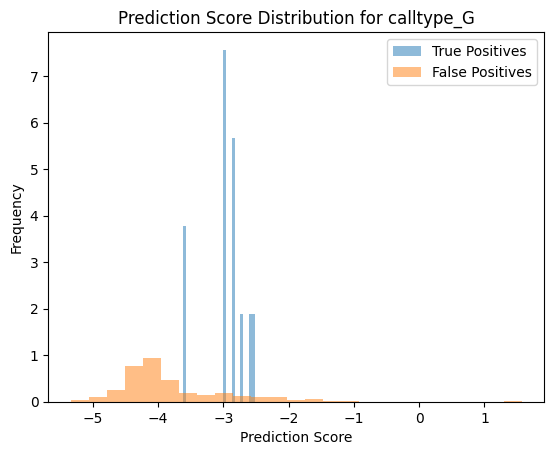

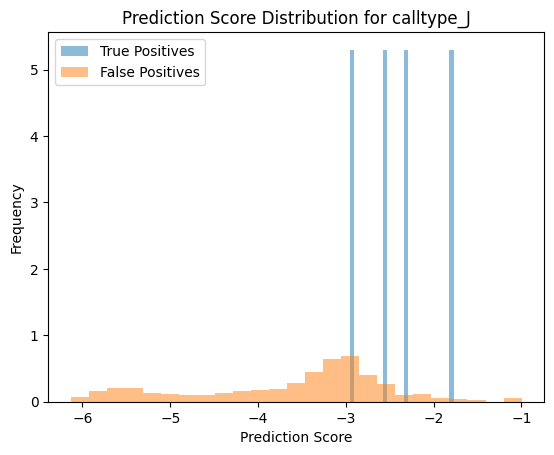

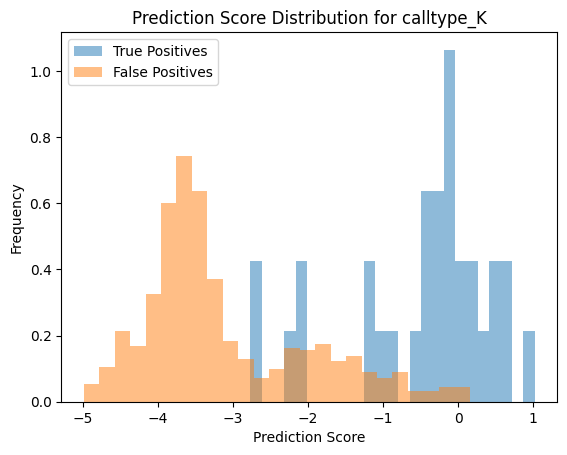

In [107]:
# Plot an histogram per calltype of the prediction scores and FP vs TP
preds = birdnet.network(torch.tensor(emb_test).cuda()).detach().cpu()

import matplotlib.pyplot as plt

for class_name in classes:
    class_idx = list(test_set.columns).index(class_name) # get index of class
    plt.figure()
    #plt.hist(preds[:, class_idx].numpy(), bins=50, alpha=0.7, label='All Predictions')
    
    # True Positives
    tp_indices = (test_set[class_name] == 1).values # get indices of true positives
    plt.hist(preds[tp_indices, class_idx].numpy(), bins=25, alpha=0.5, density=True, label='True Positives')
    
    # False Positives
    fp_indices = (test_set[class_name] == 0).values # get indices of false positives
    plt.hist(preds[fp_indices, class_idx].numpy(), bins=25, alpha=0.5, density=True, label='False Positives')
    
    plt.title(f'Prediction Score Distribution for {class_name}')
    plt.xlabel('Prediction Score')
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()

In [109]:
from sklearn.metrics import classification_report
# pred class is the class with the highest score
pred_labels = np.argmax(preds.numpy(), axis=1)
test_labels = np.argmax(test_set.values, axis=1)
report = classification_report(test_labels, pred_labels, target_names=classes, zero_division=0)
print(report)

                precision    recall  f1-score   support

    calltype_A       0.85      0.92      0.88        12
    calltype_B       1.00      0.58      0.73        45
    calltype_C       0.08      0.84      0.14        19
calltype_Check       0.89      0.37      0.53       367
calltype_Cheer       0.95      0.93      0.94       184
calltype_Chits       0.90      1.00      0.95        19
    calltype_D       0.31      0.53      0.39        34
    calltype_E       0.20      0.25      0.22        51
    calltype_G       0.00      0.00      0.00        12
    calltype_J       0.09      0.25      0.13         4
    calltype_K       0.67      0.84      0.74        31

      accuracy                           0.56       778
     macro avg       0.54      0.59      0.51       778
  weighted avg       0.79      0.56      0.61       778



In [112]:
# plot a table of number of samples in training set per class and the F1score, precision and recall in test set per class
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score
test_set = test_set.astype(float)
# Convert labels to float (in case they're boolean or object type)
train_labels = resampled_train_set.astype(float).values
val_labels = resampled_val_set.astype(float).values
test_labels = test_set.astype(float).values
test_labels = np.argmax(test_set.values, axis=1)
summary_data = []
for i, class_name in enumerate(classes):
    n_samples_train = resampled_train_set[class_name].sum()
    n_samples_val = resampled_val_set[class_name].sum()
    n_original_train = train_set[class_name].sum()
    n_original_val = val_set[class_name].sum()

    precision = precision_score(test_labels, pred_labels, average=None, zero_division=0)[i]
    recall = recall_score(test_labels, pred_labels, average=None, zero_division=0)[i]
    f1 = f1_score(test_labels, pred_labels, average=None, zero_division=0)[i]

    summary_data.append({
        'Class': class_name,
        'Num Samples (Train)': n_samples_train,
        'Num Samples (Original Train)': n_original_train,
        'Num Samples (Val)': n_samples_val,
        'Num Samples (Original Val)': n_original_val,
        'Precision (Test)': precision,
        'Recall (Test)': recall,
        'F1 Score (Test)': f1
    })
summary_df = pd.DataFrame(summary_data)
summary_df

,Class,Num Samples (Train),Num Samples (Original Train),Num Samples (Val),Num Samples (Original Val),Precision (Test),Recall (Test),F1 Score (Test)
0,calltype_A,100.0,55,9.0,9,0.846154,0.916667,0.880000
1,calltype_B,100.0,17,74.0,74,1.000000,0.577778,0.732394
2,calltype_C,100.0,97,100.0,112,0.078049,0.842105,0.142857
3,calltype_Check,100.0,2333,100.0,930,0.889610,0.373297,0.525912
4,calltype_Cheer,100.0,464,59.0,59,0.950000,0.929348,0.939560
5,calltype_Chits,100.0,125,18.0,18,0.904762,1.000000,0.950000
6,calltype_D,100.0,195,47.0,47,0.305085,0.529412,0.387097
7,calltype_E,100.0,192,29.0,29,0.200000,0.254902,0.224138
8,calltype_G,100.0,47,18.0,18,0.000000,0.000000,0.000000
9,calltype_J,100.0,19,16.0,16,0.090909,0.250000,0.133333


## confusion matrixes

Text(0.5, 1.0, 'Confusion Matrix')

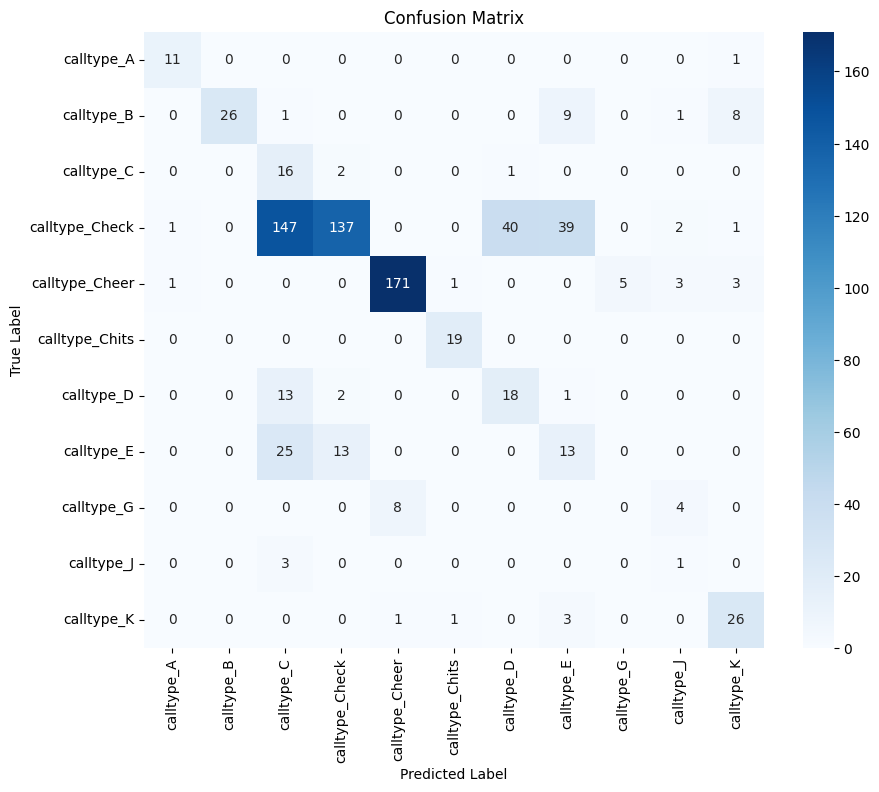

In [113]:
#is there a way to take these outputs and create a confusion matrix that lets us see what classes are being confused with each other?
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(test_labels, pred_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')   

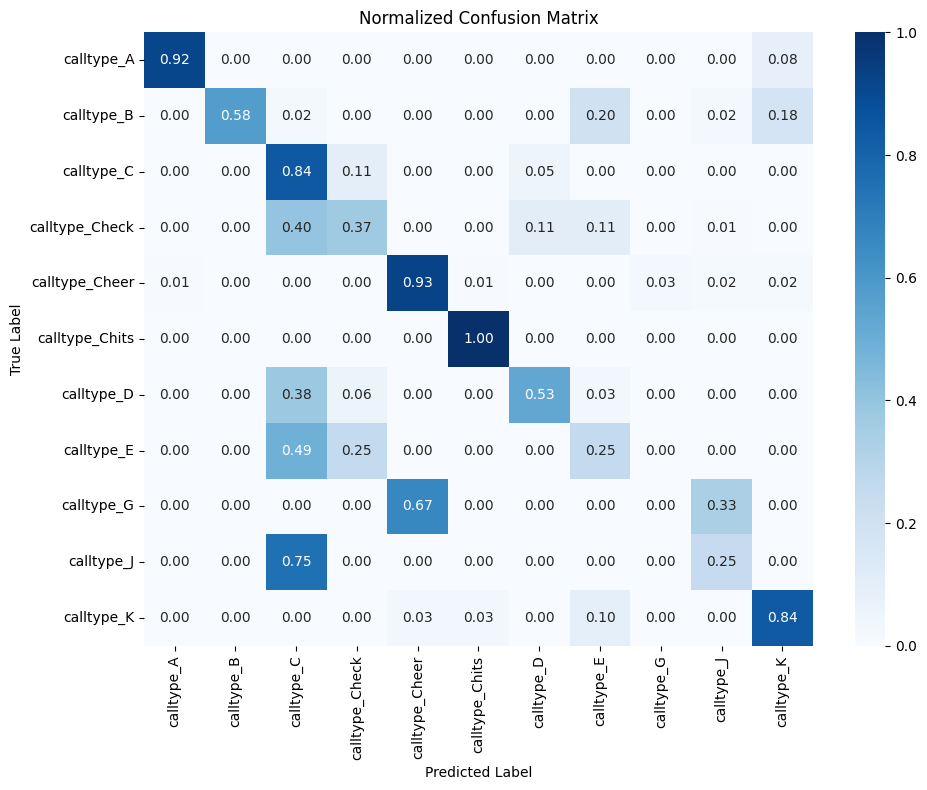

In [114]:
cm = confusion_matrix(test_labels, pred_labels)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', xticklabels=classes, yticklabels=classes, cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Normalized Confusion Matrix')
plt.tight_layout()
plt.show()

In [115]:
# Prepare results dataframe for visualization
import librosa
import soundfile as sf

# Get predictions and true labels
pred_class_indices = np.argmax(preds.numpy(), axis=1)
true_class_indices = np.argmax(test_set.values, axis=1)
confidence_scores = np.max(preds.numpy(), axis=1)

# Get file paths from test_set index
test_set_reset = test_set.reset_index()

# Create results dataframe
results_list = []
for i in range(len(test_set_reset)):
    results_list.append({
        'File': test_set_reset.iloc[i]['file'],
        'StartTime': test_set_reset.iloc[i]['start_time'],
        'EndTime': test_set_reset.iloc[i]['end_time'],
        'TrueClassIdx': true_class_indices[i],
        'PredClassIdx': pred_class_indices[i],
        'TrueClass': classes[true_class_indices[i]],
        'PredictedClass': classes[pred_class_indices[i]],
        'Confidence': confidence_scores[i],
        'Correct': true_class_indices[i] == pred_class_indices[i]
    })

df_results = pd.DataFrame(results_list)

print(f"Created results dataframe with {len(df_results)} samples")
print(f"Correct predictions: {df_results['Correct'].sum()} ({100*df_results['Correct'].mean():.1f}%)")
df_results.head()

Created results dataframe with 778 samples
Correct predictions: 438 (56.3%)


,File,StartTime,EndTime,TrueClassIdx,PredClassIdx,TrueClass,PredictedClass,Confidence,Correct
0,/home/Shelby/blackbird_calls/Experiments/Detec...,0.0,3.0,4,4,calltype_Cheer,calltype_Cheer,0.556227,True
1,/home/Shelby/blackbird_calls/Experiments/Detec...,0.0,3.0,8,4,calltype_G,calltype_Cheer,-0.490722,False
2,/home/Shelby/blackbird_calls/Experiments/Detec...,0.0,3.0,3,3,calltype_Check,calltype_Check,-0.370112,True
3,/home/Shelby/blackbird_calls/Experiments/Detec...,0.0,3.0,3,3,calltype_Check,calltype_Check,-0.208259,True
4,/home/Shelby/blackbird_calls/Experiments/Detec...,0.0,3.0,4,8,calltype_Cheer,calltype_G,0.999541,False


In [ ]:
def plot_spectrogram_results(df_results, mode='random', filter_classes=None, n_samples=25):
    """
    Plot spectrograms of predictions with varying confidence levels.
    
    Parameters:
    - df_results: DataFrame with columns 'File', 'StartTime', 'EndTime', 'TrueClass', 'PredictedClass', 'Confidence', 'Correct'
    - mode: 'max' (highest confidence), 'min' (lowest confidence), 'random', 'incorrect' (wrong predictions)
    - filter_classes: List of class names to filter by (None = all classes)
    - n_samples: Number of samples to plot (default 25)
    """
    # Filter by classes if specified
    df_filtered = df_results.copy()
    if filter_classes:
        df_filtered = df_filtered[df_filtered['PredictedClass'].isin(filter_classes)]
    
    # Select samples based on mode
    if mode == 'max':
        samples = df_filtered.sort_values(by='Confidence', ascending=False).head(n_samples)
        title_suffix = "(Highest Confidence)"
    elif mode == 'min':
        samples = df_filtered.sort_values(by='Confidence', ascending=True).head(n_samples)
        title_suffix = "(Lowest Confidence)"
    elif mode == 'incorrect':
        samples = df_filtered[df_filtered['Correct'] == False].head(n_samples)
        title_suffix = "(Incorrect Predictions)"
    else:  # random
        samples = df_filtered.sample(min(n_samples, len(df_filtered)), random_state=42)
        title_suffix = "(Random)"
    
    if len(samples) == 0:
        print("No samples found matching criteria!")
        return
    
    # Calculate grid size
    n_cols = 5
    n_rows = int(np.ceil(len(samples) / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4*n_rows))
    axes = axes.ravel() if n_rows > 1 else [axes] if n_cols == 1 else axes
    
    for i, (_, row) in enumerate(samples.iterrows()):
        if i >= len(axes):
            break
            
        # Load audio segment
        try:
            audio, sr = librosa.load(row['File'], sr=48000, 
                                    offset=row['StartTime'], 
                                    duration=row['EndTime']-row['StartTime'])
            
            # Generate mel spectrogram
            mel_spec = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=128)
            mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
            
            # Plot
            axes[i].imshow(mel_spec_db, aspect='auto', origin='lower', cmap='viridis')
            
            # Color based on correctness
            color = 'green' if row['Correct'] else 'red'
            axes[i].set_title(f"True: {row['TrueClass']}\nPred: {row['PredictedClass']} ({row['Confidence']:.2f})", 
                             color=color, fontsize=10)
            axes[i].axis('off')
        except Exception as e:
            axes[i].text(0.5, 0.5, f"Error loading:\n{str(e)[:30]}", 
                        ha='center', va='center', fontsize=8)
            axes[i].axis('off')
    
    # Hide empty subplots
    for i in range(len(samples), len(axes)):
        axes[i].axis('off')
    
    plt.suptitle(f"Spectrograms {title_suffix}", fontsize=16)
    plt.tight_layout()
    plt.show()
    
    print(f"\nDisplayed {len(samples)} samples")
    print(f"Correct: {samples['Correct'].sum()} | Incorrect: {(~samples['Correct']).sum()}")

## Visualize High and Low Confidence Predictions

In [ ]:
# Plot highest confidence predictions
plot_spectrogram_results(df_results, mode='max', n_samples=25)

In [ ]:
# Plot lowest confidence predictions
plot_spectrogram_results(df_results, mode='min', n_samples=25)

In [ ]:
# Plot incorrect predictions only
plot_spectrogram_results(df_results, mode='incorrect', n_samples=25)

In [ ]:
# Example: Filter by specific classes (e.g., only look at calltype_A and calltype_E)
# plot_spectrogram_results(df_results, mode='min', filter_classes=['calltype_A', 'calltype_E'], n_samples=20)

Save the model

In [54]:
birdnet.save("/home/Shelby/blackbird_calls/Experiments/Detection_of_calls/Datasets/All_call_classes/Split_data_controlled/OpenSoundScape/blackbirdcallv1.model")